# 04 — Time Trends
**Phase 4 — Brazilian E-Commerce Analytics (Olist)**

Business questions answered:
- How has monthly revenue and order volume trended over time?
- Which day of the week drives the most orders and revenue?
- Are there seasonal revenue patterns across months?

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import get_engine

engine = get_engine()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [11]:
try:
    with engine.connect() as conn:
        print("✅ DB connection OK")
except Exception as e:
    print(f"❌ DB connection failed: {e}")

✅ DB connection OK


In [12]:
# Check row counts before any filtering
import pandas as pd

checks = {
    "orders_clean total rows":      "SELECT COUNT(*) FROM orders_clean",
    "orders delivered":             "SELECT COUNT(*) FROM orders_clean WHERE order_status = 'delivered'",
    "order_payments total rows":    "SELECT COUNT(*) FROM order_payments",
    "distinct order_status values": "SELECT DISTINCT order_status FROM orders_clean",
}

for label, q in checks.items():
    result = pd.read_sql(q, engine)
    print(f"\n{label}:")
    print(result.to_string(index=False))


orders_clean total rows:
 count
 99441

orders delivered:
 count
 96478

order_payments total rows:
 count
103886

distinct order_status values:
order_status
     shipped
 unavailable
    invoiced
     created
    approved
  processing
   delivered
    canceled


In [4]:
# Single query — one JOIN, one scan, no repeated DB hits
query = """
    SELECT
        o.order_id,
        o.order_purchase_timestamp,
        op.payment_value
    FROM orders_clean o
    JOIN order_payments op ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
"""

df = pd.read_sql(query, engine)
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
print(f"Loaded {len(df):,} rows")

Loaded 100,756 rows


In [5]:
# Monthly — deduplicate order_id before summing payment_value
df_orders = df.drop_duplicates(subset="order_id")
df["month"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
df_orders["month"] = df_orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df.groupby("month", as_index=False)
    .agg(revenue=("payment_value", "sum"),
         total_orders=("order_id", "nunique"))
)
monthly["revenue"] = monthly["revenue"].round(2)

# Day of week
df_orders["day_num"]     = df_orders["order_purchase_timestamp"].dt.dayofweek  # Mon=0
df_orders["day_of_week"] = df_orders["order_purchase_timestamp"].dt.day_name()

daily = (
    df_orders.groupby(["day_num", "day_of_week"], as_index=False)
    .agg(total_orders=("order_id", "nunique"),
         revenue=("payment_value", "sum"))
    .sort_values("day_num")
)
daily["revenue"] = daily["revenue"].round(2)

# Seasonal (month of year)
df_orders["month_num"]  = df_orders["order_purchase_timestamp"].dt.month
df_orders["month_name"] = df_orders["order_purchase_timestamp"].dt.strftime("%B")

seasonal = (
    df_orders.groupby(["month_num", "month_name"], as_index=False)
    .agg(revenue=("payment_value", "sum"),
         total_orders=("order_id", "nunique"))
    .sort_values("month_num")
)
seasonal["revenue"] = seasonal["revenue"].round(2)

In [13]:
# Check df loaded correctly after the fetch cell
print(f"df shape: {df.shape}")
print(f"df dtypes:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
print(df.head(3))

df shape: (100756, 4)
df dtypes:
order_id                               str
order_purchase_timestamp    datetime64[us]
payment_value                      float64
month                       datetime64[us]
dtype: object

First 3 rows:
                           order_id order_purchase_timestamp  payment_value  \
0  a9810da82917af2d9aefd1278f1dcfa0      2018-06-26 11:01:38          24.39   
1  ba78997921bbcdc1373bb41e913ab953      2017-12-06 12:04:06         107.78   
2  42fdf880ba16b47b59251dd489d4441a      2018-05-21 13:59:17         128.45   

       month  
0 2018-06-01  
1 2017-12-01  
2 2018-05-01  


matplotlib backend: module://matplotlib_inline.backend_inline


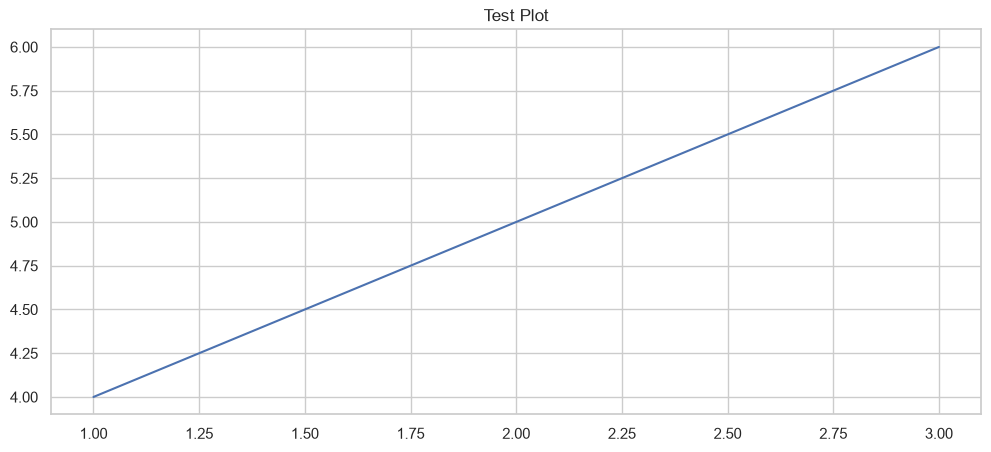

plot cell done


In [14]:
# Minimal plot test
import matplotlib
print(f"matplotlib backend: {matplotlib.get_backend()}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("Test Plot")
plt.show()
print("plot cell done")

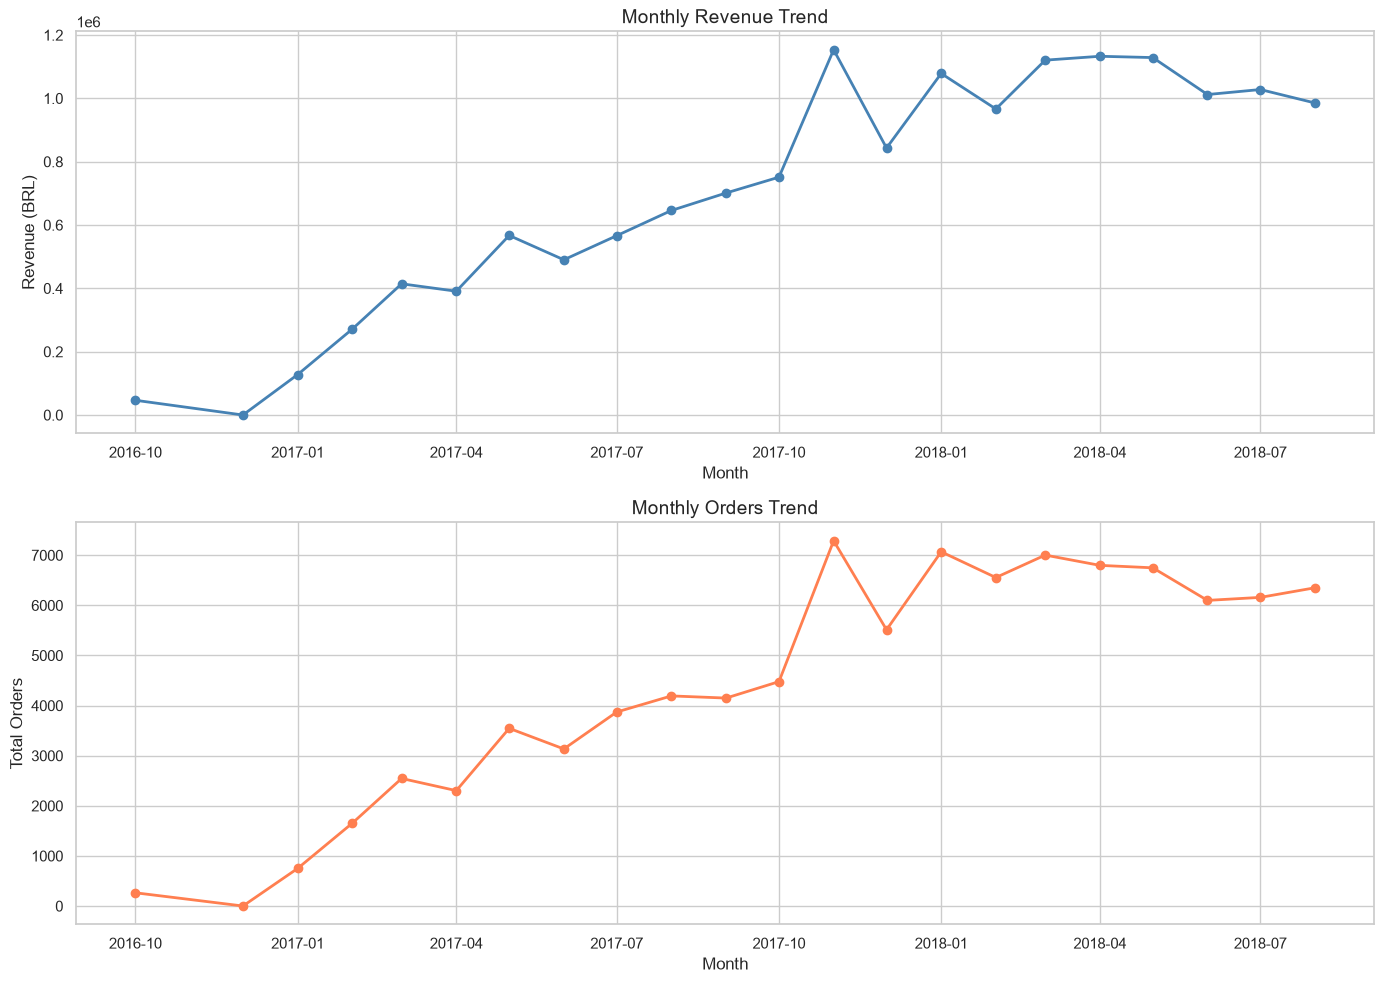

,month,revenue,total_orders
0,2016-10-01,46566.71,265
1,2016-12-01,19.62,1
2,2017-01-01,127545.67,750
3,2017-02-01,271298.65,1653
4,2017-03-01,414369.39,2546
5,2017-04-01,390952.18,2303
6,2017-05-01,567066.73,3546
7,2017-06-01,490225.60,3135
8,2017-07-01,566403.93,3872
9,2017-08-01,646000.61,4193


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(monthly["month"], monthly["revenue"], marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Monthly Revenue Trend", fontsize=14)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (BRL)")

axes[1].plot(monthly["month"], monthly["total_orders"], marker="o", color="coral", linewidth=2)
axes[1].set_title("Monthly Orders Trend", fontsize=14)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Orders")

plt.tight_layout()
plt.show()
monthly

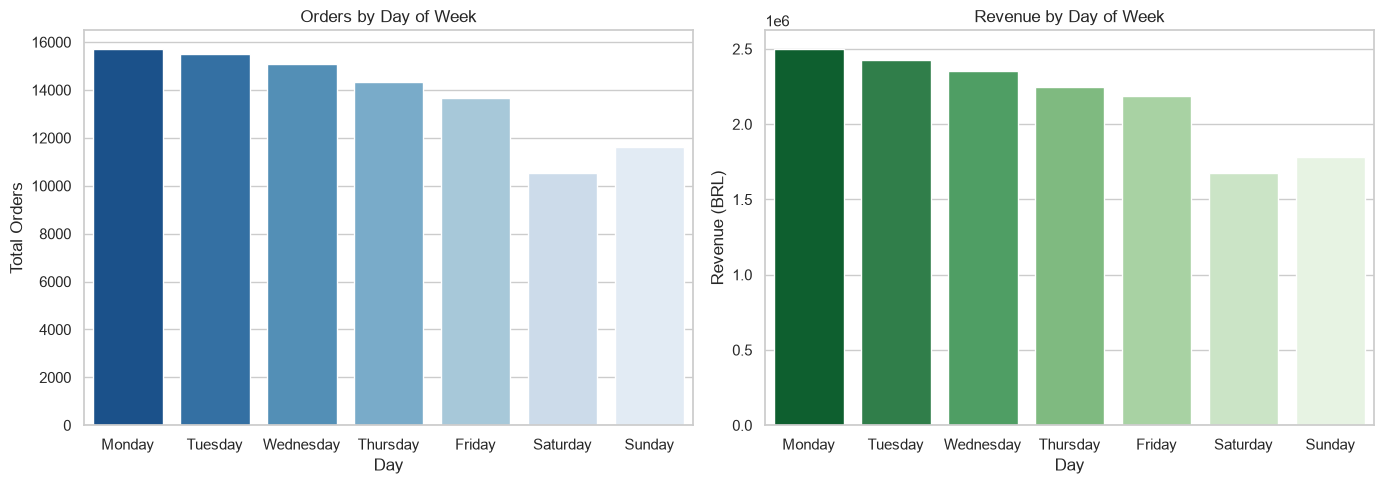

,day_num,day_of_week,total_orders,revenue
0,0,Monday,15701,2497696.56
1,1,Tuesday,15503,2429522.11
2,2,Wednesday,15076,2351500.53
3,3,Thursday,14322,2248486.24
4,4,Friday,13685,2184855.57
5,5,Saturday,10555,1677485.76
6,6,Sunday,11635,1779465.66


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=daily, x="day_of_week", y="total_orders",
    hue="day_of_week", palette="Blues_r", legend=False, ax=axes[0]
)
axes[0].set_title("Orders by Day of Week")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Total Orders")

sns.barplot(
    data=daily, x="day_of_week", y="revenue",
    hue="day_of_week", palette="Greens_r", legend=False, ax=axes[1]
)
axes[1].set_title("Revenue by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Revenue (BRL)")

plt.tight_layout()
plt.show()
daily

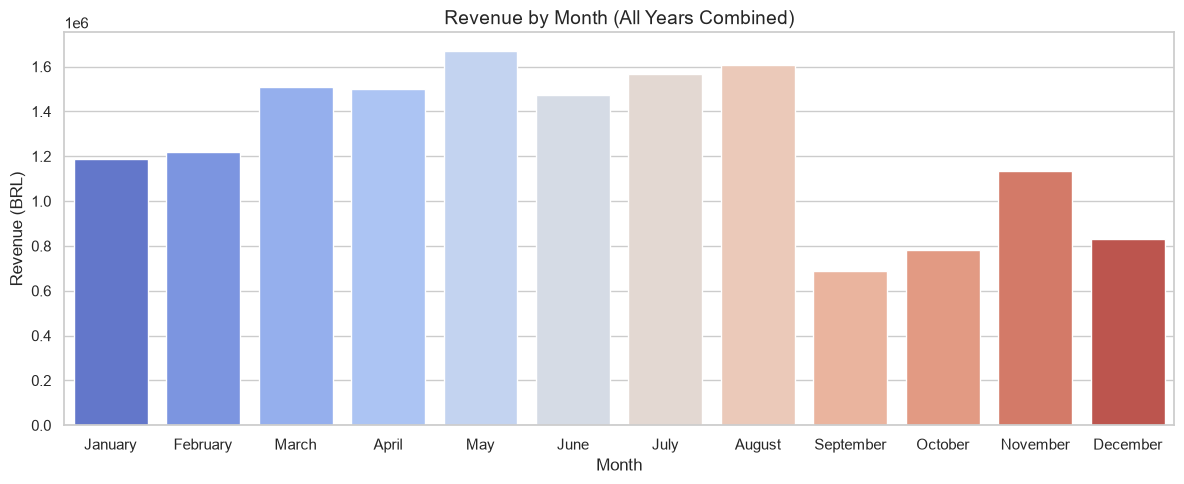

,month_num,month_name,revenue,total_orders
0,1,January,1186079.47,7819
1,2,February,1220877.76,8208
2,3,March,1511173.59,9549
3,4,April,1498383.54,9101
4,5,May,1668769.21,10295
5,6,June,1472758.38,9234
6,7,July,1567607.35,10031
7,8,August,1606875.02,10544
8,9,September,687423.04,4150
9,10,October,783276.44,4743


In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=seasonal, x="month_name", y="revenue",
    hue="month_name", palette="coolwarm", legend=False
)
plt.title("Revenue by Month (All Years Combined)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.tight_layout()
plt.show()
seasonal